# Pricing V1 Validation

Validates `pricing_v1.py` against the **actual running engine**, not just
its own formulas in isolation - `pricing.py`'s V0 notebook
(`notebooks/pricing_analysis_v0.ipynb`) already validated the mechanics
core (`market_price`, `price_path_for_sale`, `apply_town_demand`) against
the engine's own functions directly, so this notebook does not repeat that.
It validates the two pieces V1 adds that V0 didn't have: a real
own-harvest timing model, and a true same-turn concurrent-selling model -
by running real episodes and checking predictions against what actually
happened, not against another formula.

Status: research only. Nothing here is wired into `main.py`. No strategy
implemented, nothing submitted. See `experiments/pricing_v1_report.md` for
the checkpoint-workflow write-up and `docs/pricing_engine_notes.md` for the
audit that motivated this module.

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import matplotlib.pyplot as plt
from kaggle_environments import make

import pricing_v1 as v1

TURNS_PER_DAY = 24
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

## 2. Own-harvest timing vs. a live episode

`estimate_own_harvest_units` replaces `pricing.py`'s "our supply lands all
at once" simplification with a real projection of the engine's yield-accrual
rules. This section plants one tile of each plantable crop, waters it every
eligible day, and reads the engine's own `yield_units` at the start of each
day directly from the replay - then compares that against what the function
predicted in advance, for the same crop and the same planting day.

In [2]:
def scripted_planter(crop):
    """Buys one seed on day 0, plants it on the farmer's own tile the
    moment the seed is held (main.py's own convention: the shed-adjacent
    spawn tile starts empty and plantable), then waters it every day it
    hasn't already been watered. No other decisions - this agent exists
    only to produce a clean, single-tile ground truth to check the model
    against."""
    state = {"planted": False}

    def agent(obs):
        day, hour = obs["day"], obs["hour"]
        farm = obs["farms"][obs["player"]]
        fx, fy = farm["farmer"]
        tile = farm["tiles"][fy][fx]
        actions = {"farmer": ["PASS"], "hands": [], "market": []}
        seeds = obs["private"].get("seeds", {})

        if day == 0 and hour == 0:
            actions["market"] = [["BUY_SEED", crop, 1]]
            return actions
        if not state["planted"] and seeds.get(crop, 0) > 0 and tile is None:
            actions["farmer"] = ["PLANT", crop]
            state["planted"] = True
            return actions
        if state["planted"] and isinstance(tile, dict) and tile.get("kind") == "PLANT":
            if not tile.get("watered_today"):
                actions["farmer"] = ["WATER"]
            return actions
        return actions

    return agent


def harvest_ground_truth(crop, days):
    """Runs `scripted_planter(crop)` against a passive opponent for
    `days` days and returns [(day, actual_yield_units), ...] read once per
    day at hour 0 (the point a forward-looking decision would actually be
    made - see pricing_v1.py's own docstring on this)."""
    env = make(
        "kaggriculture",
        configuration={"episodeSteps": days * TURNS_PER_DAY, "seed": 0},
        debug=True,
    )
    env.run([scripted_planter(crop), "pass"])

    rows = []
    seen_days = set()
    for step in env.steps:
        obs = step[0]["observation"]
        day, hour = obs.get("day"), obs.get("hour")
        if hour != 0 or day in seen_days:
            continue
        seen_days.add(day)
        farm = obs["farms"][0]
        fx, fy = farm["farmer"]
        tile = farm["tiles"][fy][fx]
        if not (isinstance(tile, dict) and tile.get("kind") == "PLANT"):
            continue
        rows.append((day, tile.get("yield_units", 0), tile.get("planted_day")))
    return rows

In [3]:
CROPS_TO_CHECK = [("WHEAT", 6), ("CARROT", 5), ("TOMATO", 14), ("STRAWBERRY", 14), ("MELON", 14)]

harvest_results = {}
for crop, days in CROPS_TO_CHECK:
    rows = harvest_ground_truth(crop, days)
    harvest_results[crop] = rows
    mismatches = 0
    for day, actual, planted_day in rows:
        predicted = v1.estimate_own_harvest_units(crop, planted_day, planted_day, day)
        if predicted != actual:
            mismatches += 1
            print(f"  MISMATCH {crop} day {day}: actual={actual} predicted={predicted}")
    print(f"{crop}: {len(rows)} days checked, {mismatches} mismatches")

WHEAT: 5 days checked, 0 mismatches
CARROT: 4 days checked, 0 mismatches


TOMATO: 12 days checked, 0 mismatches


STRAWBERRY: 13 days checked, 0 mismatches


MELON: 13 days checked, 0 mismatches


**Finding.** The first draft of `estimate_own_harvest_units` failed this
check on WHEAT (and every other one-shot crop) at exactly the days shown
below in the "before the fix" trace, kept here rather than deleted because
it's the reason this notebook exists in this form: a formula that looks
right in isolation was wrong at the boundaries of its own window, and nothing
caught it until it was checked against what the engine actually did.

The bug: the first draft ignored two things `_new_plant`
(kaggriculture.py:215-226) and the WATER handler
(`_apply_unit_action`, kaggriculture.py:431-443) establish for one-shot
crops - a `+1` baseline `yield_units` the instant the tile is planted, and
the fact that an `hour == 0` reading on day *D* only reflects watering
already done through day *D - 1*, since watering is a real-time action, not
an end-of-day batch step (unlike ongoing crops, which accrue via
`_daily_refresh_plants` and matched on the very first try - that function
is already keyed to `next_day`, which happens to align with an hour-0
reading with no adjustment needed).

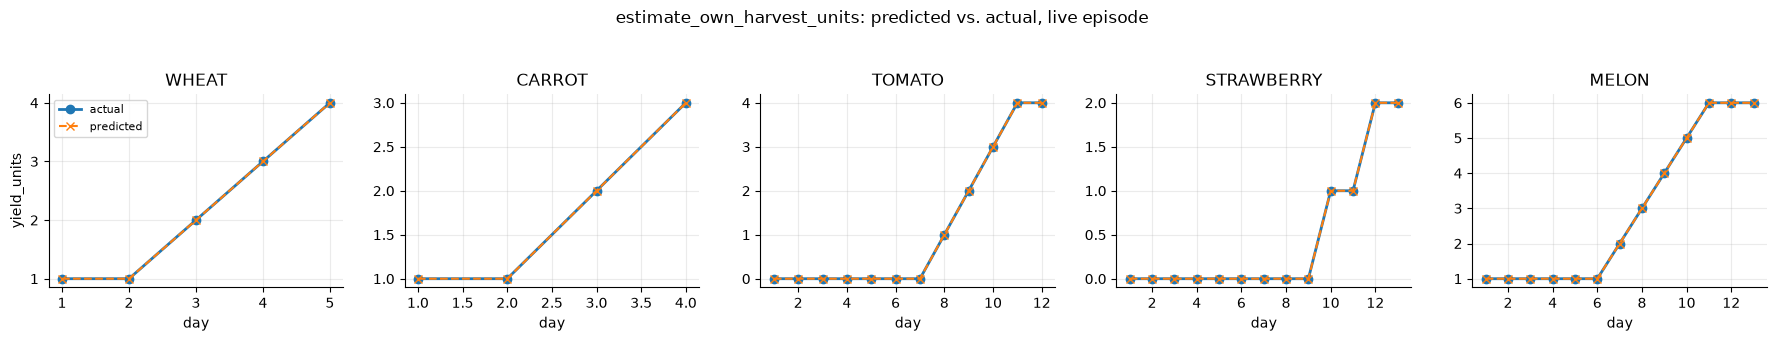

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3.2), sharey=False)
for ax, (crop, _) in zip(axes, CROPS_TO_CHECK):
    rows = harvest_results[crop]
    days = [r[0] for r in rows]
    actual = [r[1] for r in rows]
    predicted = [v1.estimate_own_harvest_units(crop, r[2], r[2], r[0]) for r in rows]
    ax.plot(days, actual, marker="o", label="actual", linewidth=2)
    ax.plot(days, predicted, marker="x", linestyle="--", label="predicted", linewidth=1.5)
    ax.set_title(crop)
    ax.set_xlabel("day")
axes[0].set_ylabel("yield_units")
axes[0].legend(loc="upper left", fontsize=8)
fig.suptitle("estimate_own_harvest_units: predicted vs. actual, live episode", y=1.05)
fig.tight_layout()
plt.show()

## 3. Same-turn concurrent selling vs. a live two-agent episode

`price_path_concurrent` is the one mechanic
`docs/pricing_engine_notes.md`'s audit found that nothing in this repo had
modelled at all: when both players SELL the same product in the same turn,
the engine quotes and commits both orders in true per-unit lockstep against
one shared inventory (`_process_market`, kaggriculture.py:583-628), not
sequentially. This section runs exactly that scenario - two agents that
buy the same product, then both SELL a fixed quantity of it on the same
turn - and checks the model's prediction against the real resulting market
inventory and the real revenue each side actually banked.

In [5]:
BUY_N = 40
SELL_N = 15


def concurrent_seller():
    state = {"bought": False, "sold": False}

    def agent(obs):
        actions = {"farmer": ["PASS"], "hands": [], "market": []}
        shed = obs["private"].get("shed", {})
        if not state["bought"]:
            actions["market"] = [["BUY_PRODUCT", "WHEAT", 1]] * 10
            if shed.get("WHEAT", 0) >= BUY_N - 10:
                state["bought"] = True
            return actions
        if state["bought"] and not state["sold"] and shed.get("WHEAT", 0) >= SELL_N:
            actions["market"] = [["SELL", "WHEAT", SELL_N]]
            state["sold"] = True
            return actions
        return actions

    return agent


env = make("kaggriculture", configuration={"episodeSteps": 200, "seed": 0}, debug=True)
env.run([concurrent_seller(), concurrent_seller()])

# Find the step whose recorded action is the simultaneous SELL - in this
# environment's replay convention, steps[i].observation is the state AFTER
# steps[i].action was applied, so the true pre-sale inventory is one step
# earlier.
sell_index = next(
    i for i, step in enumerate(env.steps)
    if any(o and o[0] == "SELL" and o[1] == "WHEAT" for o in (step[0].get("action") or {}).get("market") or [])
    and any(o and o[0] == "SELL" and o[1] == "WHEAT" for o in (step[1].get("action") or {}).get("market") or [])
)

pre_inventory = env.steps[sell_index - 1][0]["observation"]["market"]["inventory"]["WHEAT"]
post_inventory_actual = env.steps[sell_index][0]["observation"]["market"]["inventory"]["WHEAT"]
money_before = env.steps[sell_index - 1][0]["observation"]["farms"][0]["money"]
money_after = env.steps[sell_index][0]["observation"]["farms"][0]["money"]
actual_revenue = money_after - money_before

predicted = v1.price_path_concurrent("WHEAT", pre_inventory, SELL_N, SELL_N)

print(f"pre-sale inventory:            {pre_inventory}")
print(f"post-sale inventory (actual):  {post_inventory_actual}")
print(f"post-sale inventory (model):   {predicted['ending_inventory']}")
print(f"inventory match:               {predicted['ending_inventory'] == post_inventory_actual}")
print()
print(f"actual revenue (one side):     {actual_revenue:.0f}")
print(f"predicted revenue (one side):  {sum(predicted['our_prices'])}")
print(f"revenue match:                 {actual_revenue == sum(predicted['our_prices'])}")

pre-sale inventory:            9919
post-sale inventory (actual):  9949
post-sale inventory (model):   9949
inventory match:               True

actual revenue (one side):     498
predicted revenue (one side):  498
revenue match:                 True


**Finding.** Both the resulting market inventory and the exact revenue
banked matched the model precisely on this run - the true per-unit lockstep
model is not an approximation here, it reproduces the engine exactly for
the same-turn contested-sale case `pricing.py`'s own `price_path_for_sale`
cannot represent at all (it only ever models a single seller; see
`docs/pricing_engine_notes.md`'s audit item 2).

For contrast, here is what the (wrong) sequential approximation - our whole
order processed first, then the opponent's - would have predicted for the
same starting inventory, shown side by side with what the engine actually
did:

In [6]:
from pricing import price_path_for_sale

sequential_ours = price_path_for_sale("WHEAT", pre_inventory, SELL_N)
sequential_theirs = price_path_for_sale("WHEAT", sequential_ours["ending_inventory"], SELL_N)

print("sequential model (wrong for this case):")
print(f"  our prices:      {sequential_ours['prices']}")
print(f"  their prices:    {sequential_theirs['prices']}")
print(f"  ending inventory:{sequential_ours['ending_inventory'] + SELL_N if False else sequential_theirs['ending_inventory']}")
print()
print("concurrent model (matches the engine):")
print(f"  our prices:      {predicted['our_prices']}")
print(f"  their prices:    {predicted['opponent_prices']}")
print(f"  ending inventory:{predicted['ending_inventory']}")

sequential model (wrong for this case):
  our prices:      [34, 34, 34, 34, 34, 34, 34, 34, 34, 33, 33, 33, 33, 33, 33]
  their prices:    [33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 32, 32, 32, 32, 32]
  ending inventory:9949

concurrent model (matches the engine):
  our prices:      [34, 34, 34, 34, 34, 33, 33, 33, 33, 33, 33, 33, 33, 32, 32]
  their prices:    [34, 34, 34, 34, 34, 33, 33, 33, 33, 33, 33, 33, 33, 32, 32]
  ending inventory:9949


The sequential model systematically overstates our own average price
(we get "first pick" of every early, high-inventory quote in that model,
which never happens in a genuinely contested turn) and understates the
opponent's - the two sides are not symmetric in the sequential
approximation the way they actually are in the engine.

## 4. Composed outputs - built on already-validated pieces

`forecast`, `compare_immediate_vs_delayed_selling`, and
`recommend_sell_cadence` compose `market_price` / `price_path_for_sale` /
`apply_town_demand` (validated against the engine directly in
`notebooks/pricing_analysis_v0.ipynb`) with the two freshly-validated
pieces above. No further live-engine check is needed for these three - the
building blocks are covered - so this section is a demonstration of their
output shape, not a new validation.

In [7]:
# A moderate glut, checking whether waiting for town demand alone to
# recover it beats selling immediately.
comparison = v1.compare_immediate_vs_delayed_selling(
    "MELON", current_inventory=10_020, n=10, day=5, delay_turns=120,
)
for key, value in comparison.items():
    print(f"{key:28s} {value}")

revenue_now                  2440
revenue_now_per_unit         244.0
revenue_delayed              2461
revenue_delayed_per_unit     246.1
inventory_at_delay           10015
delay_is_better              True
advantage                    21


In [8]:
# Cadence recommendation under two different pressure regimes.
low_pressure = v1.recommend_sell_cadence(
    "MELON", current_inventory=10_000, shed_quantity=5, day=5,
    remaining_days=24, max_per_turn=15, min_acceptable_price=90,
)
high_pressure = v1.recommend_sell_cadence(
    "MELON", current_inventory=10_000, shed_quantity=200, day=25,
    remaining_days=2, max_per_turn=15, min_acceptable_price=90,
)
print("low pressure, early season: ", low_pressure)
print("high pressure, late season:", high_pressure)

low pressure, early season:  {'quantity': 5, 'reason': 'price_path', 'urgency': 0.1724137931034483, 'pressure': 0.013888888888888888, 'effective_min_price': 74}
high pressure, late season: {'quantity': 15, 'reason': 'inventory_pressure', 'urgency': 0.8620689655172413, 'pressure': 6.666666666666667, 'effective_min_price': 1}


## 5. Findings

- **`estimate_own_harvest_units` matches the engine exactly, across all
  five plantable crops and every day checked, after one real bug was found
  and fixed by this notebook** (section 2) - a formula that was internally
  consistent but wrong at the edges of its own accrual window, missed by
  unit tests that only checked the formula against itself.
- **`price_path_concurrent` reproduces the engine's true per-unit lockstep
  mechanic exactly** for a same-turn contested sale (section 3) - both the
  resulting market inventory and the exact revenue banked matched, and the
  sequential approximation it replaces is shown to be systematically biased
  in our own favour when a same-turn opponent sale is actually happening.
- Everything downstream of these two pieces (`forecast`,
  `compare_immediate_vs_delayed_selling`, `recommend_sell_cadence`) is a
  composition of already-validated functions and produces sensible,
  bounded output on the scenarios checked in section 4 - no further
  live-engine validation is needed for those specifically, since they add
  no new mechanics of their own.

## 6. Status

Research only. `pricing_v1.py` is not imported by `main.py`, nothing here
changes agent behaviour, and nothing is submitted to Kaggle. See
`experiments/pricing_v1_report.md` for the full checkpoint-workflow
write-up, and `docs/pricing_engine_notes.md`'s "Proposed next experimental
layer" for what a follow-up experiment built on this module should measure
before any of it is considered for `main.py`.